# Q3 Mixed Asset Class Portfolio Optimization Framework
###   *by Dr. W. Vera-Tudela*

## 1. Introduction & Objective

This notebook develops a multi-asset portfolio optimisation framework using historical market data.

The objective is to examine how portfolio risk and expected return change when assets from different classes are combined, and to compare several portfolio-construction approaches within the same universe.

The analysis includes:

- an equal-weight portfolio as a baseline;
- mean-variance optimisation using the Markowitz framework;
- minimum-variance and maximum-Sharpe portfolios;
- target-return optimisation;
- and a Black-Litterman allocation incorporating investor views.

The main focus is on the effect of cross-asset diversification on portfolio volatility, expected return, correlation structure, and optimal asset weights.

The framework is implemented in Python using a Jupyter notebook together with supporting functions in `Q3_functions.py`.


## 2. Data Pipeline

The analysis follows six main stages:

1. **Data acquisition and alignment**
   - Fetch historical price data for stocks, cryptocurrencies, ETFs, and bonds.
   - Align the assets to a common analysis period.
   - Prepare the price series for return and covariance estimation.

2. **Return and risk estimation**
   - Compute daily returns.
   - Estimate annualized expected returns and volatility.
   - Estimate the annualized covariance matrix.
   - Visualize correlation and covariance structures.

3. **Mean-variance optimisation**
   - Compute portfolio return and volatility for a given set of weights.
   - Construct the efficient frontier across a range of target returns.
   - Generate random portfolios through Monte Carlo simulation for comparison.

4. **Key portfolio allocations**
   - Equal-weight portfolio as a baseline.
   - Target-return portfolio minimizing volatility at the equal-weight expected return.
   - Global minimum-variance portfolio.
   - Maximum-Sharpe portfolio under long-only, fully invested constraints.

5. **Black-Litterman model**
   - Estimate market-capitalization weights and equilibrium returns.
   - Define investor views through the matrices \(P\), \(Q\), and \($\Omega$\).
   - Compute posterior expected returns.
   - Re-optimize the portfolio using the Black-Litterman expected returns.
   - Examine sensitivity to the chosen views and confidence assumptions.

6. **Visualization and comparison**
   - Plot the efficient frontier and simulated portfolios.
   - Highlight individual assets and key optimized portfolios.
   - Compare portfolio weights across methods.
   - Compare historical portfolio value paths for the selected allocations.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.append("../utils")

from common import fetch_portfolio_data, return_statistics

from Q3_functions import (
    global_min_variance,
    frontier_optimizer,
    max_sharpe,
    portfolio_return,
    portfolio_volatility,
    min_variance,
    historical_portfolio_value
)

## 3. Data Preparation & Risk Estimation

Historical market data is downloaded using `fetch_portfolio_data()`.

The shared function `return_statistics()` then:

- computes daily asset returns;
- estimates annualized expected returns;
- estimates annualized volatility;
- constructs the annualized covariance matrix;
- and calculates the daily return correlation matrix.

These estimates provide the inputs for the portfolio-optimization methods used in the following sections.

In [2]:
# Load data
starting_capital = 100_000

start = pd.Timestamp("2016-01-01")
end = pd.Timestamp("2025-12-31")

tickersS = ["AAPL", "NVDA", "CVX", "TSM"]
tickersC = ["BTC-USD", "ETH-USD"]
tickersE = ["SPY", "VEA", "GLD", "TLT"]

dataS, _ = fetch_portfolio_data(tickersS, start, end)
dataC, _ = fetch_portfolio_data(tickersC, start, end)
dataE, _ = fetch_portfolio_data(tickersE, start, end)

In [3]:
# Check individual datasets
print(dataS.shape)
print(dataS.isna().sum())
print(dataS.index.min(), dataS.index.max())
print()

print(dataC.shape)
print(dataC.isna().sum())
print(dataC.index.min(), dataC.index.max())
print()

print(dataE.shape)
print(dataE.isna().sum())
print(dataE.index.min(), dataE.index.max())
print()


# Align all assets on common trading dates
dataALL = pd.concat([dataS, dataC, dataE], axis=1, join="inner")
dataALL = (dataALL.dropna().sort_index())

print(dataALL.shape)
print(dataALL.index.min(), dataALL.index.max())

(2513, 4)
Ticker
AAPL    0
CVX     0
NVDA    0
TSM     0
dtype: int64
2016-01-04 00:00:00 2025-12-30 00:00:00

(2974, 2)
Ticker
BTC-USD    0
ETH-USD    0
dtype: int64
2017-11-09 00:00:00 2025-12-30 00:00:00

(2513, 4)
Ticker
GLD    0
SPY    0
TLT    0
VEA    0
dtype: int64
2016-01-04 00:00:00 2025-12-30 00:00:00

(2045, 10)
2017-11-09 00:00:00 2025-12-30 00:00:00


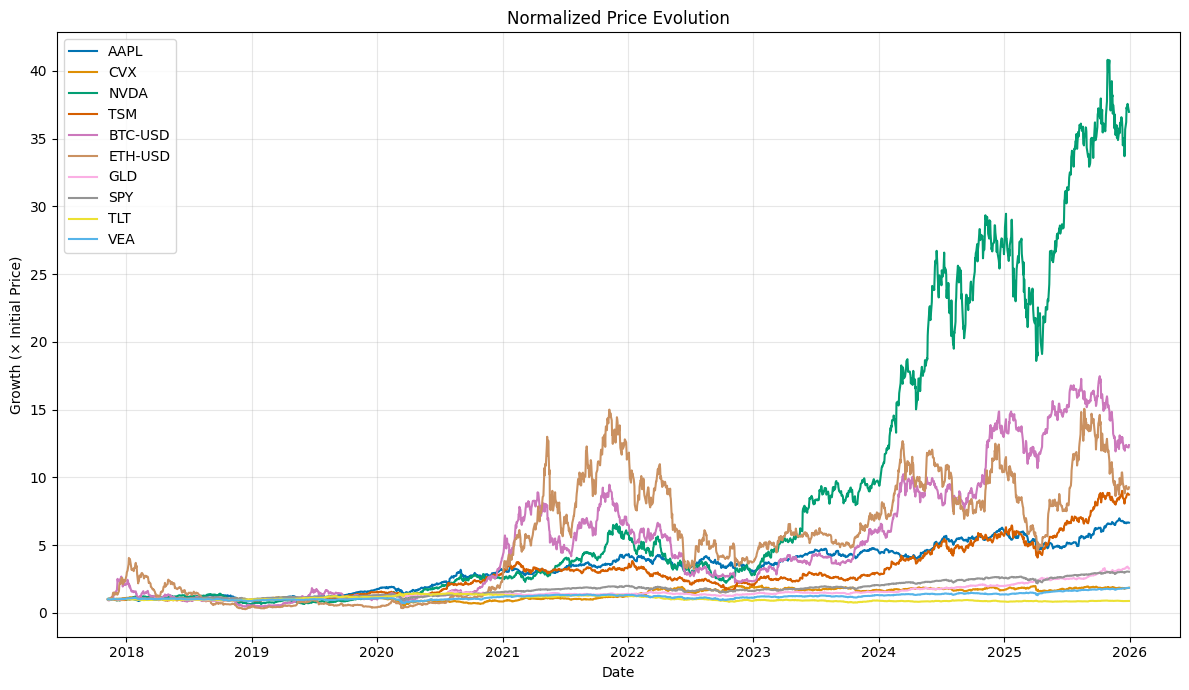

In [ ]:
assets = dataALL.columns.tolist()

colors = sns.color_palette(
    "colorblind",
    n_colors=len(assets),
)

plt.figure(figsize=(12, 7))

for asset, color in zip(assets, colors):
    plt.plot(
        dataALL[asset] / dataALL[asset].iloc[0],
        label=asset,
        color=color,
    )

plt.title("Normalized Price Evolution")
plt.xlabel("Date")
plt.ylabel("Growth (× Initial Price)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

,Annualized Return,Annualized Volatility
Ticker,,
AAPL,28.1%,30.6%
CVX,12.5%,31.1%
NVDA,57.6%,51.1%
TSM,33.1%,35.9%
BTC-USD,53.3%,66.5%
ETH-USD,65.3%,86.9%
GLD,15.7%,15.1%
SPY,15.5%,19.3%
TLT,-0.4%,15.7%


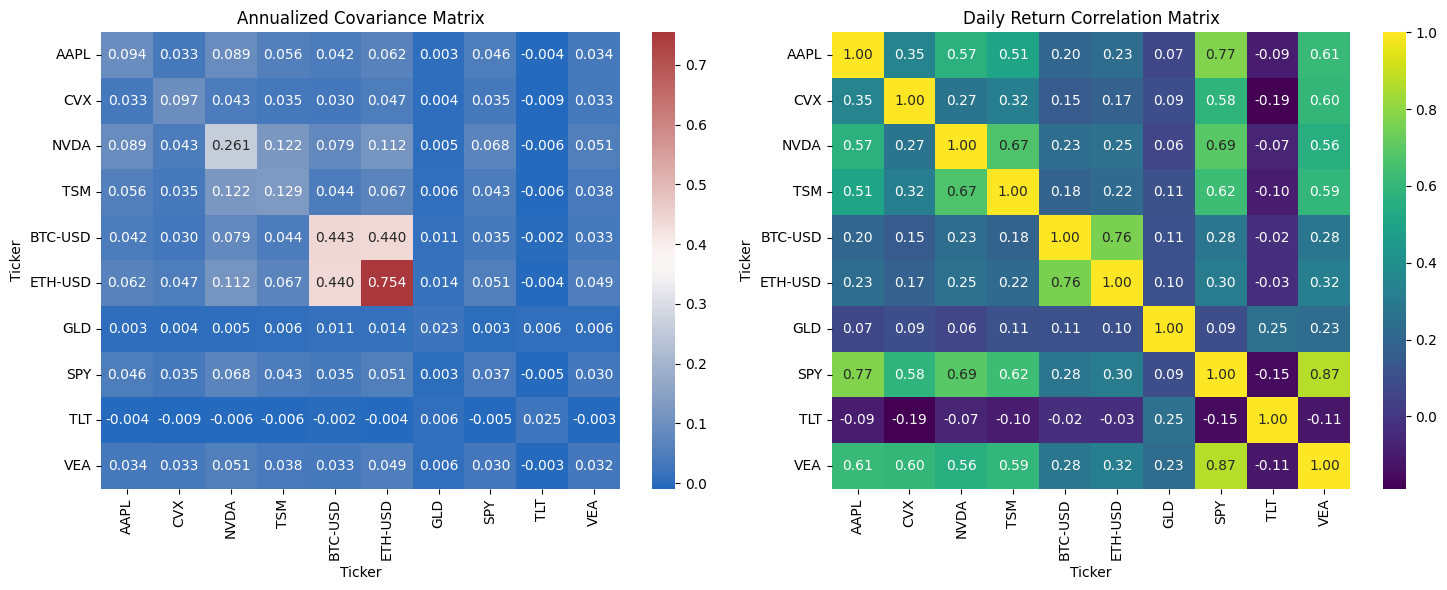

In [ ]:
_, mu_annual, sigma_annual, cov_annual, corr_matrix = (return_statistics(dataALL))

# Annualized return and volatility

stats = pd.concat(
    [mu_annual, sigma_annual],
    axis=1,
)

stats.columns = [
    "Annualized Return",
    "Annualized Volatility",
]

display(
    stats.style.format("{:.1%}")
)

# Covariance and correlation structure

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(
    cov_annual,
    annot=True,
    fmt=".3f",
    cmap="vlag",
    ax=axes[0],
)

axes[0].set_title("Annualized Covariance Matrix")

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    ax=axes[1],
)

axes[1].set_title("Daily Return Correlation Matrix")

plt.tight_layout()
plt.show()

## 4. Efficient Frontier - Markowitz Model

The efficient frontier is constructed using `frontier_optimizer()`, which solves a sequence of constrained minimum-variance problems across a range of target expected returns.

For each target return, the optimizer identifies the long-only, fully invested portfolio with the lowest estimated volatility.

A Monte Carlo sample of randomly generated portfolio weights is then used as a visual reference. Each random portfolio is evaluated using the same expected-return and covariance estimates, allowing the optimized frontier to be compared with the broader feasible portfolio set.

In [ ]:
gmv_result = global_min_variance(cov_annual)

gmv_weights = gmv_result.x

gmv_return = portfolio_return(gmv_weights, mu_annual)

return_max = mu_annual.max()

target_returns = np.linspace(gmv_return, return_max, 100)

frontier_volatilities, frontier_returns, _ = (frontier_optimizer(mu_annual, cov_annual, target_returns))

In [ ]:
n_simulations = 10_000
rf = 0.04
np.random.seed(42)

sim_returns = []
sim_vols = []
sim_sharpes = []

for _ in range(n_simulations):

    w = np.random.dirichlet(np.ones(len(assets)))

    r = portfolio_return(w, mu_annual)

    v = portfolio_volatility(w, cov_annual)

    s = (
        (r - rf) / v
        if v > 0
        else np.nan
    )

    sim_returns.append(r)
    sim_vols.append(v)
    sim_sharpes.append(s)

## 5. Key Portfolios

After constructing the efficient frontier and the random portfolio sample, four representative allocations are selected for comparison:

- **Equal-weight portfolio**  
  Each asset receives the same weight. This provides a simple, non-optimized baseline.

- **Target-return minimum-variance portfolio**  
  The portfolio is optimized to achieve the same expected return as the equal-weight portfolio while minimizing estimated volatility.

- **Global minimum-variance portfolio**  
  This is the long-only, fully invested portfolio with the lowest estimated volatility across the entire feasible set.

- **Maximum-Sharpe portfolio**  
  The portfolio maximizes the Sharpe ratio subject to the same long-only, fully invested constraints.

In [8]:
# Equal-weight portfolio
w_equal = np.ones(len(assets)) / len(assets)

ret_equal = portfolio_return(w_equal, mu_annual)

vol_equal = portfolio_volatility(w_equal, cov_annual)

sharpe_equal = (ret_equal - rf) / vol_equal

In [9]:
# Target-return minimum-variance portfolio

result = min_variance(ret_equal, mu_annual, cov_annual)

if not result.success:
    raise RuntimeError(f"Target-return optimization failed: {result.message}")

w_optimized = result.x

ret_optimized = portfolio_return(w_optimized, mu_annual)

vol_optimized = portfolio_volatility(w_optimized, cov_annual)

sharpe_optimized = (ret_optimized - rf) / vol_optimized

print(
    f"Equal weight: ret={ret_equal:.3f}, "
    f"vol={vol_equal:.3f}, "
    f"sharpe={sharpe_equal:.3f}"
)

print(
    f"Optimized:    ret={ret_optimized:.3f}, "
    f"vol={vol_optimized:.3f}, "
    f"sharpe={sharpe_optimized:.3f}"
)

print(
    "Volatility reduction: "
    f"{(1 - vol_optimized / vol_equal) * 100:.1f}%"
)

Equal weight: ret=0.290, vol=0.237, sharpe=1.053
Optimized:    ret=0.290, vol=0.184, sharpe=1.359
Volatility reduction: 22.5%


In [10]:
# Global minimum-variance portfolio

if not gmv_result.success:
    raise RuntimeError(
        f"GMV optimization failed: {gmv_result.message}"
    )

w_min = gmv_result.x

ret_min = portfolio_return(w_min, mu_annual)

vol_min = portfolio_volatility(w_min, cov_annual)

sharpe_min = (ret_min - rf) / vol_min

print(f"Return: {ret_min:.4f}")
print(f"Minimum Volatility: {vol_min:.4f}")
print(f"Sharpe: {sharpe_min:.4f}")

Return: 0.0874
Minimum Volatility: 0.1003
Sharpe: 0.4725


In [11]:
# Maximum-Sharpe portfolio

sharpe_result = max_sharpe(mu_annual, cov_annual, rf=rf)

if not sharpe_result.success:
    raise RuntimeError(
        f"Maximum-Sharpe optimization failed: {sharpe_result.message}"
    )

w_max_sharpe = sharpe_result.x

ret_max_sharpe = portfolio_return(w_max_sharpe, mu_annual)

vol_max_sharpe = portfolio_volatility(w_max_sharpe, cov_annual)

sharpe_max = (ret_max_sharpe - rf) / vol_max_sharpe

print(f"Return: {ret_max_sharpe:.4f}")
print(f"Volatility: {vol_max_sharpe:.4f}")
print(f"Sharpe Ratio: {sharpe_max:.4f}")

Return: 0.2924
Volatility: 0.1858
Sharpe Ratio: 1.3590


## 6. Black-Litterman Model

The Black-Litterman model is used to combine a reference portfolio with explicit investor views, producing an adjusted set of expected returns for portfolio optimisation.

The analysis proceeds through four steps:

- **Reference allocation and equilibrium returns**  
  Define a prior portfolio allocation and use it together with the covariance matrix to estimate implied equilibrium returns.

- **Investor views**  
  Express relative or absolute views through the view matrix \($P$\), view vector \($Q$\), and uncertainty matrix \($\Omega$\).

- **Posterior expected returns**  
  Combine the equilibrium prior with the investor views to obtain the Black-Litterman posterior expected returns.

- **Portfolio re-optimisation and sensitivity analysis**  
  Re-run the portfolio optimisation using the posterior returns and examine how the resulting allocation changes with the strength and confidence of the views.

In [12]:
# Step 1 - Reference portfolio
# Equal-weight prior across the mixed-asset universe
w_prior = pd.Series(1 / len(assets), index=assets)

# Step 2 - Equilibrium returns
risk_aversion = 2.5

pi = risk_aversion * (cov_annual @ w_prior)

# Step 3 - Investor view
tau = 0.05

# View:
# the average expected return of AAPL, NVDA, and BTC
# exceeds ETH by 5 percentage points

view = pd.Series(0.0, index=assets)

view["AAPL"] = 1 / 3
view["NVDA"] = 1 / 3
view["BTC-USD"] = 1 / 3
view["ETH-USD"] = -1.0

P = view.to_numpy().reshape(1, -1)

Q = np.array([0.05])

# View uncertainty proportional to the variance
# of the view portfolio
omega = (
    tau
    * P
    @ cov_annual.to_numpy()
    @ P.T
)

# Step 4 - Black-Litterman posterior

Sigma = cov_annual.to_numpy()
pi_vec = pi.to_numpy()

M1 = np.linalg.inv(
    tau * Sigma
)

M2 = (
    P.T
    @ np.linalg.inv(omega)
    @ P
)

M3 = (
    M1 @ pi_vec
    + P.T
    @ np.linalg.inv(omega)
    @ Q
)

mu_bl = np.linalg.solve(M1 + M2, M3)

mu_bl = pd.Series(mu_bl, index=assets, name="BL_Return")

display(pd.DataFrame({"Equilibrium_Return": pi, "BL_Return": mu_bl}).style.format("{:.1%}"))

,Equilibrium_Return,BL_Return
AAPL,11.3%,11.7%
CVX,8.7%,8.4%
NVDA,20.6%,21.4%
TSM,13.4%,13.5%
BTC-USD,28.9%,22.4%
ETH-USD,39.8%,25.8%
GLD,2.0%,1.8%
SPY,8.6%,8.6%
TLT,-0.2%,-0.2%
VEA,7.6%,7.3%


In [13]:
# Black-Litterman optimized portfolio

# Reference prior portfolio evaluated under BL expected returns
ret_prior_bl = portfolio_return(w_prior, mu_bl)
vol_prior = portfolio_volatility(w_prior, cov_annual)
sharpe_prior_bl = (ret_prior_bl - rf) / vol_prior


# Optimize using Black-Litterman posterior returns
bl_result = max_sharpe(mu_bl, cov_annual, rf=rf)

if not bl_result.success:
    raise RuntimeError(f"Black-Litterman optimization failed: {bl_result.message}")

w_bl = bl_result.x
ret_bl = portfolio_return(w_bl, mu_bl)
vol_bl = portfolio_volatility(w_bl, cov_annual)
sharpe_bl = (ret_bl - rf) / vol_bl


print(
    f"Prior: ret={ret_prior_bl:.3f}, "
    f"vol={vol_prior:.3f}, "
    f"sharpe={sharpe_prior_bl:.3f}"
)

print(
    f"BL:    ret={ret_bl:.3f}, "
    f"vol={vol_bl:.3f}, "
    f"sharpe={sharpe_bl:.3f}"
)

display(pd.Series(w_bl, index=assets, name="BL Weight").to_frame().style.format("{:.1%}"))

Prior: ret=0.121, vol=0.237, sharpe=0.340
BL:    ret=0.189, vol=0.371, sharpe=0.402


,BL Weight
AAPL,14.0%
CVX,5.3%
NVDA,41.8%
TSM,10.8%
BTC-USD,24.6%
ETH-USD,3.6%
GLD,0.0%
SPY,0.0%
TLT,0.0%
VEA,0.0%


## 7. Visualization

Three main figures summarize the portfolio-allocation results:

1. **Efficient frontier and random portfolios**  
   The efficient frontier is shown together with the Monte Carlo sample of random long-only portfolios, colored by Sharpe ratio. Key optimized portfolios and individual assets are highlighted for comparison.

2. **Historical portfolio value paths**  
   The selected portfolio allocations are applied to the observed asset returns to compare how each allocation would have evolved over the historical sample.

3. **Portfolio weight comparison**  
   Asset weights are compared across the equal-weight, target-return, global minimum-variance, maximum-Sharpe, and Black-Litterman portfolios.

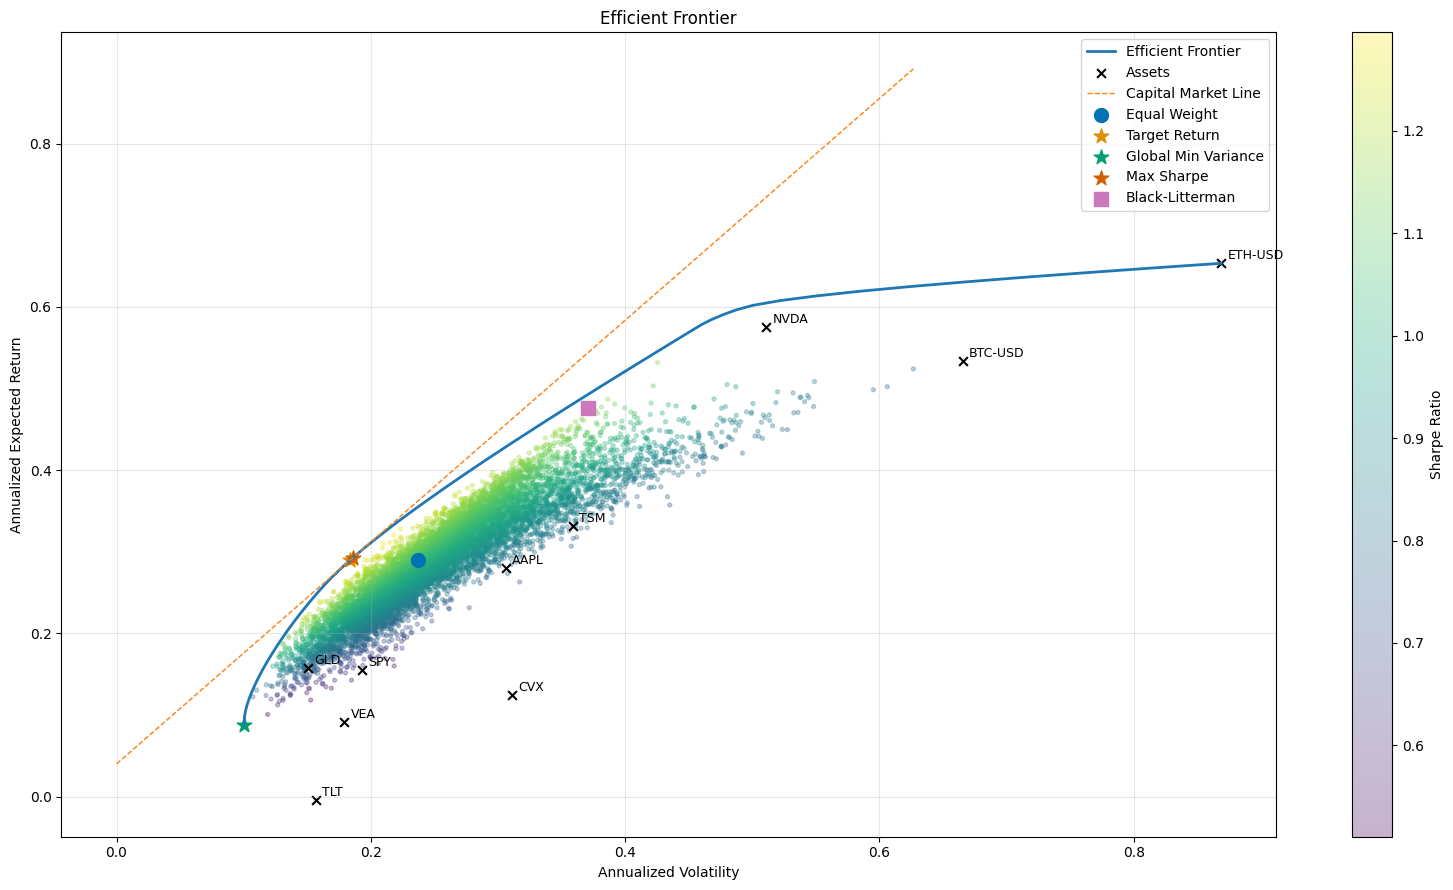

In [14]:
ret_bl_hist = portfolio_return(w_bl, mu_annual)

plt.figure(figsize=(16, 9))
colors = sns.color_palette("colorblind")

# Efficient frontier
plt.plot(frontier_volatilities, frontier_returns, linewidth=2, label="Efficient Frontier")

# Random portfolios
scatter = plt.scatter(sim_vols, sim_returns, c=sim_sharpes, cmap="viridis", alpha=0.3, s=8)
plt.colorbar(scatter, label="Sharpe Ratio")

# Individual assets
plt.scatter(sigma_annual, mu_annual, s=40, color="black", marker="x", label="Assets")

for asset in assets:
    plt.annotate(asset, (sigma_annual[asset] + 0.005, mu_annual[asset] + 0.005), fontsize=9)

# Capital Market Line
cml_x = np.linspace(0, max(sim_vols), 100)
cml_y = (rf + sharpe_max * cml_x)

plt.plot( cml_x, cml_y, linestyle="--", linewidth=1, label="Capital Market Line")

# Equal-weight portfolio
plt.scatter(vol_equal, ret_equal, s=100, marker="o", color=colors[0], label="Equal Weight")

# Target-return minimum-variance portfolio
plt.scatter(vol_optimized, ret_optimized, s=120, marker="*", color=colors[1], label="Target Return")

# Global minimum-variance portfolio
plt.scatter(vol_min, ret_min, s=120, marker="*", color=colors[2], label="Global Min Variance")

# Maximum-Sharpe portfolio
plt.scatter(vol_max_sharpe, ret_max_sharpe, s=120, marker="*", color=colors[3], label="Max Sharpe")

# Black-Litterman allocation,
# evaluated using historical moments for comparability
plt.scatter(vol_bl, ret_bl_hist, s=100, marker="s", color=colors[4], label="Black-Litterman")

plt.grid(True, alpha=0.3)
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Expected Return")
plt.title("Efficient Frontier")
plt.legend()

plt.tight_layout()
plt.show()

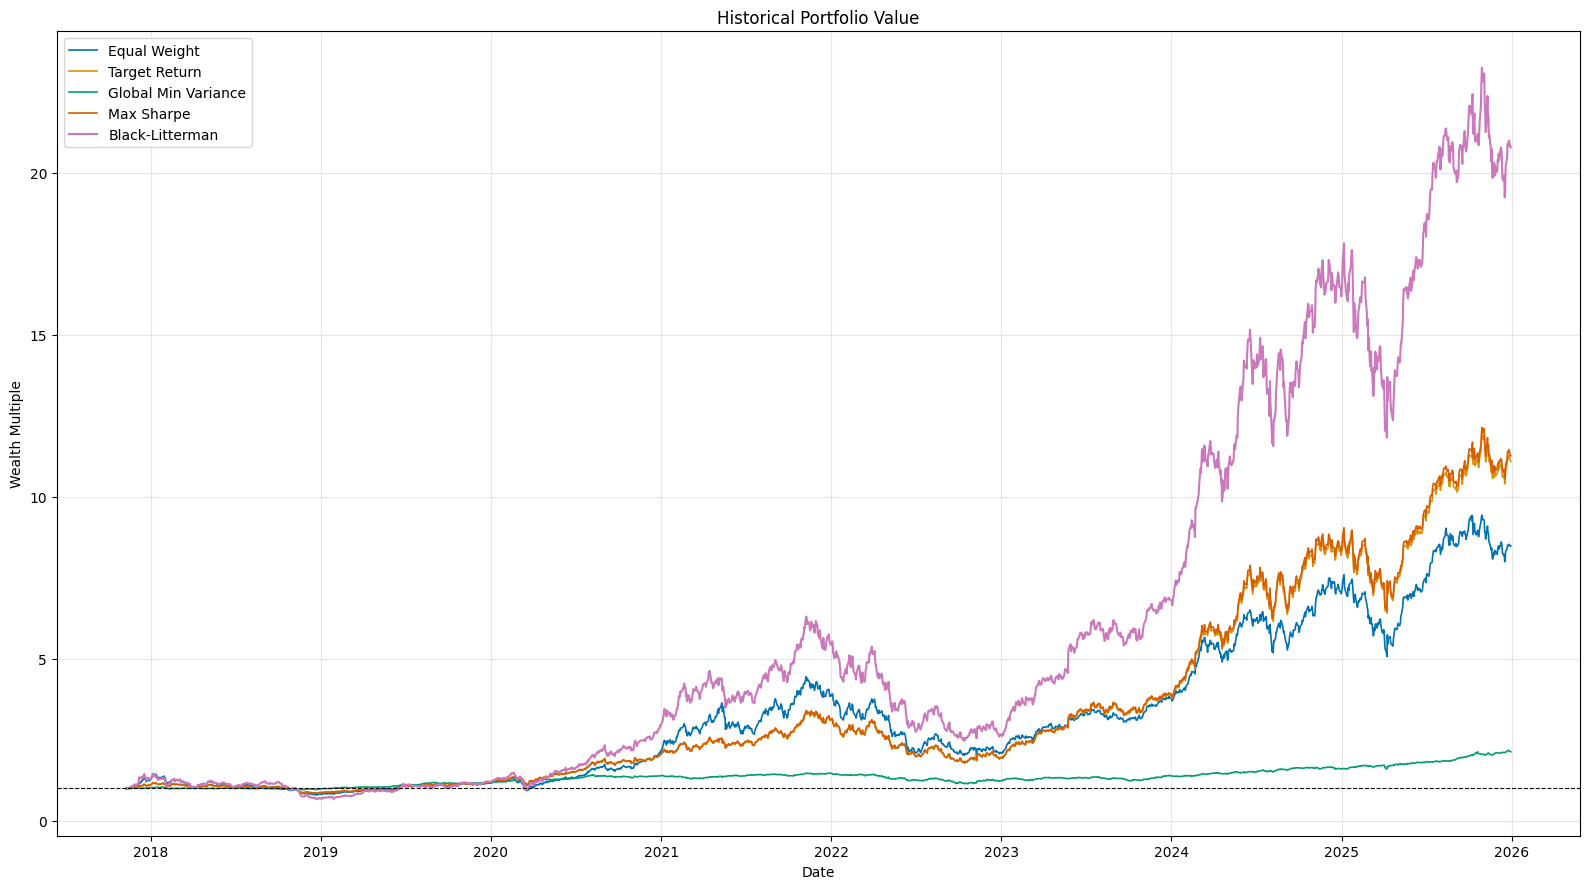

In [15]:
port_value_equal = historical_portfolio_value(dataALL, w_equal, starting_capital)
port_value_optimized = historical_portfolio_value(dataALL, w_optimized, starting_capital)
port_value_min = historical_portfolio_value(dataALL, w_min, starting_capital)
port_value_max_sharpe = historical_portfolio_value(dataALL, w_max_sharpe, starting_capital)
port_value_bl = historical_portfolio_value(dataALL, w_bl, starting_capital)

plt.figure(figsize=(16, 9))

colors = sns.color_palette("colorblind", n_colors=5)

plt.plot(port_value_equal.index, port_value_equal / starting_capital, color=colors[0], label="Equal Weight", linewidth=1.2)
plt.plot(port_value_optimized.index, port_value_optimized / starting_capital, color=colors[1], label="Target Return", linewidth=1.2)
plt.plot(port_value_min.index, port_value_min / starting_capital, color=colors[2], label="Global Min Variance", linewidth=1.2)
plt.plot(port_value_max_sharpe.index, port_value_max_sharpe / starting_capital, color=colors[3], label="Max Sharpe", linewidth=1.2)
plt.plot(port_value_bl.index, port_value_bl / starting_capital, color=colors[4], label="Black-Litterman", linewidth=1.5)
plt.axhline(1.0, color="black", linestyle="--", linewidth=0.8)

plt.title("Historical Portfolio Value")
plt.xlabel("Date")
plt.ylabel("Wealth Multiple")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

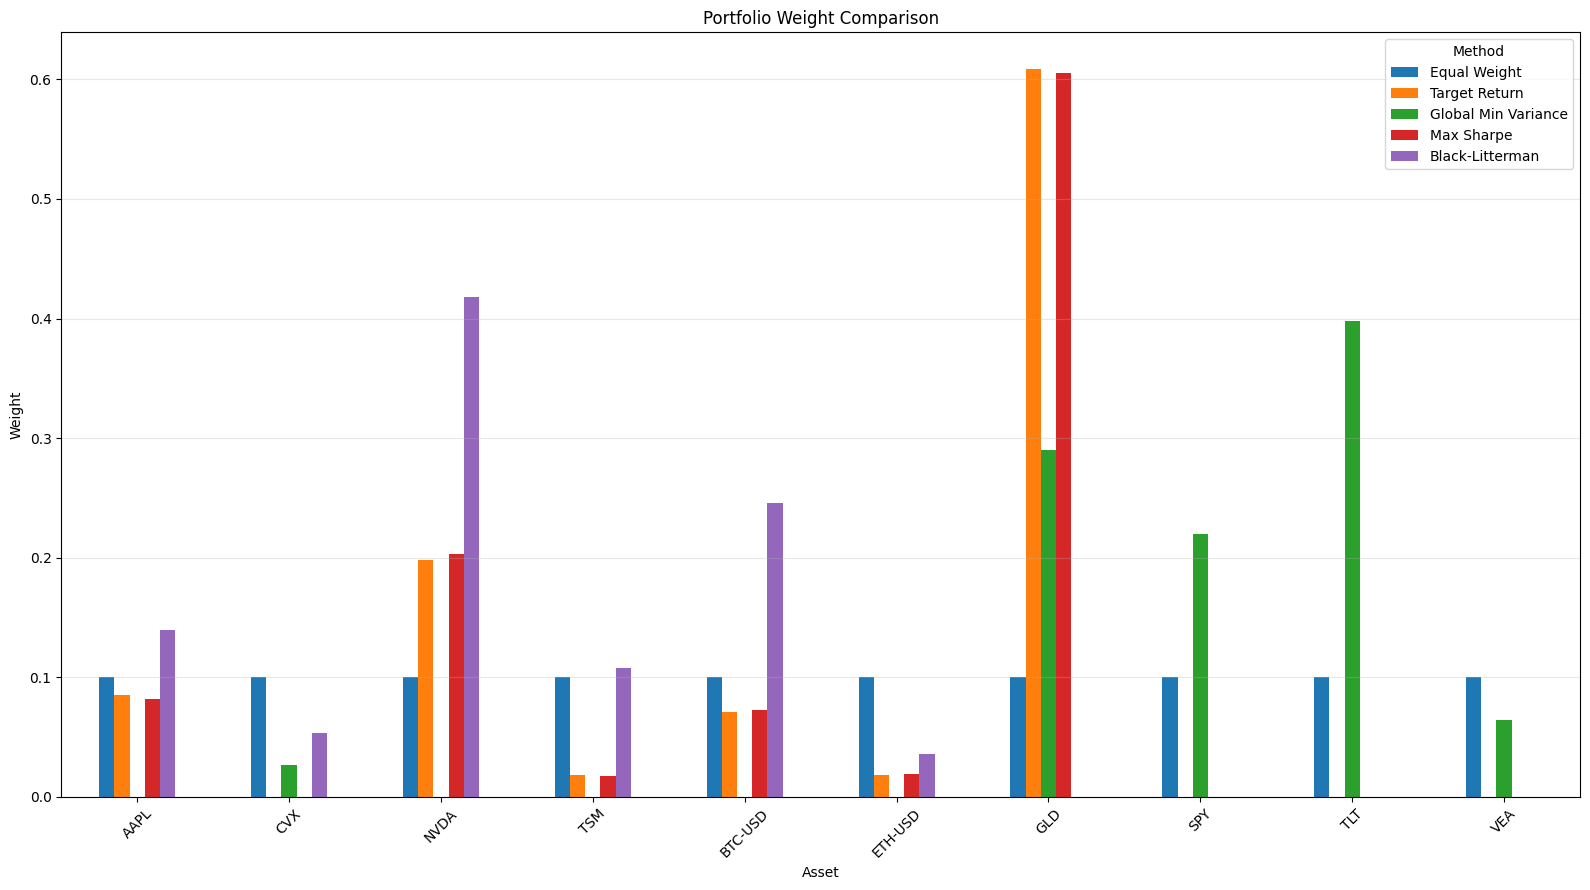

In [16]:
weights_df = pd.DataFrame(
    {
        "Equal Weight": w_equal,
        "Target Return": w_optimized,
        "Global Min Variance": w_min,
        "Max Sharpe": w_max_sharpe,
        "Black-Litterman": w_bl,
    },
    index=assets,
)

weights_df.plot(kind="bar", figsize=(16, 9))

plt.title("Portfolio Weight Comparison")
plt.ylabel("Weight")
plt.xlabel("Asset")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Method")

plt.tight_layout()
plt.show()

## 8. Conclusions

This notebook examines portfolio construction across a mixed universe of equities, cryptocurrencies, gold, broad-market ETFs, international equities, and long-duration Treasury bonds.

The analysis compares five allocations: equal weight, target-return minimum variance, global minimum variance, maximum Sharpe, and Black-Litterman.

The main findings are:

- **Cross-asset diversification materially changes the opportunity set.**  
  Assets with different return and correlation structures allow the optimizer to construct portfolios that cannot be replicated simply by redistributing weights among closely related equities. The efficient frontier therefore reflects not only differences in individual asset risk and return, but also the diversification benefit created by covariance across asset classes.

- **The covariance structure is as important as individual asset volatility.**  
  Assets with relatively modest standalone returns can still receive meaningful portfolio weights when they contribute diversification. Conversely, an asset with attractive historical performance may receive little or no weight if its risk contribution is redundant with other assets already in the portfolio.

- **The global minimum-variance portfolio emphasizes diversification rather than return maximization.**  
  Its allocation is determined entirely by the covariance structure under the long-only, fully invested constraints. As expected, its historical wealth path is substantially less aggressive than the higher-return optimized portfolios.

- **The target-return and maximum-Sharpe portfolios happen to be similar in this sample.**  
  They solve different optimization problems, but the equal-weight portfolio's expected return lies close to the tangency region of the estimated efficient frontier. This similarity is therefore sample-specific rather than a general property of the two methods.

- **Maximum-Sharpe optimization can produce concentrated allocations.**  
  Historical mean returns are estimated with substantial uncertainty, and assets with unusually favorable estimated return-to-risk characteristics can dominate the solution. Position-weight constraints would therefore be a useful sensitivity test rather than an assumption that the unconstrained allocation is practically optimal.

- **Black-Litterman changes the source of expected-return information rather than the covariance structure.**  
  In this implementation, an equal-weight reference portfolio is used to construct equilibrium returns, and a relative investor view is then incorporated to obtain posterior expected returns. The resulting allocation can differ substantially from the historical-mean maximum-Sharpe portfolio because the two methods use different expected-return inputs.

- **The historical portfolio-value comparison is descriptive, not predictive.**  
  The portfolio weights are estimated using the same historical sample over which their wealth paths are displayed. These paths therefore illustrate how the resulting allocations interact with the observed historical data, but they do not constitute an out-of-sample performance test.

Overall, the experiment demonstrates that portfolio optimization is driven by the interaction between expected returns, volatility, covariance, constraints, and prior assumptions. The resulting weights should therefore be interpreted as model outputs conditional on those inputs rather than as uniquely optimal investment allocations.

## 9. Limitations & Next Steps

The main limitations of this baseline framework are:

1. **In-sample optimization**  
   Portfolio weights are estimated from the same historical sample over which the wealth paths are displayed. The resulting performance comparison is therefore descriptive rather than out-of-sample evidence. A more rigorous evaluation would use rolling or expanding estimation windows and test each allocation only on subsequent unseen data.

2. **Static initial weights with no rebalancing**  
   The selected allocations are applied once at the beginning of the sample and then allowed to drift as asset prices change. This means the realized portfolio can diverge substantially from its initial target weights over time. Periodic rebalancing would keep allocations closer to their targets but would introduce turnover and transaction costs.

3. **Expected-return estimation uncertainty**  
   Mean-variance optimization is highly sensitive to expected-return inputs. Historical arithmetic means can be noisy, particularly for volatile assets such as cryptocurrencies and high-growth equities, and small changes in these estimates can lead to large changes in optimal weights.

4. **Simplified Black-Litterman prior and views**  
   The Black-Litterman implementation uses an equal-weight reference allocation and a small set of manually specified views. Different priors, confidence assumptions, or view structures could materially change the posterior expected returns and resulting portfolio weights.

5. **Mixed-market calendar treatment**  
   The analysis uses only dates observed across all assets. This avoids forward-filling non-trading days, but it also discards some information from assets such as cryptocurrencies that trade continuously. Weekly-return aggregation is a useful alternative for future work.

6. **Fixed risk-free rate**  
   A constant annual risk-free rate of 4% is used for Sharpe-ratio calculations. A time-varying short-term risk-free proxy would provide a more realistic historical comparison.

Possible next steps include:

- implementing rolling-window optimization with out-of-sample evaluation;
- adding periodic rebalancing and transaction costs;
- testing maximum-position constraints as a concentration sensitivity analysis;
- comparing daily common-date estimates with weekly-return estimates;
- introducing tracking-error or turnover penalties;
- evaluating alternative Black-Litterman priors and view-confidence assumptions;
- and extending the framework to robust or shrinkage-based covariance and expected-return estimates.